# Fake News Detection




## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [ ]:
!pip install --upgrade numpy==1.26.4
!pip install --upgrade pandas==2.2.2
!pip install --upgrade nltk==3.9.1
!pip install --upgrade spacy==3.7.5
!pip install --upgrade scipy==1.12
!pip install --upgrade pydantic==2.10.5
!pip install wordcloud==1.9.4
!python -m spacy download en_core_web_sm

   ---------------------------------------- 0.0/45.8 MB ? eta -:--:--
    --------------------------------------- 0.8/45.8 MB 4.2 MB/s eta 0:00:11
   - -------------------------------------- 1.6/45.8 MB 3.8 MB/s eta 0:00:12
   -- ------------------------------------- 2.4/45.8 MB 3.9 MB/s eta 0:00:12
   -- ------------------------------------- 2.9/45.8 MB 3.4 MB/s eta 0:00:13
   --- ------------------------------------ 3.7/45.8 MB 3.6 MB/s eta 0:00:12
   ---- ----------------------------------- 5.5/45.8 MB 4.2 MB/s eta 0:00:10
   ------ --------------------------------- 7.1/45.8 MB 4.6 MB/s eta 0:00:09
   ------- -------------------------------- 8.4/45.8 MB 4.9 MB/s eta 0:00:08
   -------- ------------------------------- 9.7/45.8 MB 5.1 MB/s eta 0:00:08
   --------- ------------------------------ 11.0/45.8 MB 5.1 MB/s eta 0:00:07
   ---------- ----------------------------- 12.6/45.8 MB 5.3 MB/s eta 0:00:07
   ------------ --------------------------- 13.9/45.8 MB 5.4 MB/s eta 0:00:06
   

## Importing the necessary libraries

In [ ]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
from nltk.corpus import stopwords  # For stopwords
from nltk.stem import WordNetLemmatizer  # For lemmatization
from nltk.tokenize import word_tokenize, sent_tokenize  # For tokenization
from nltk import pos_tag  # For part-of-speech tagging
from collections import Counter  # For counting occurrences of elements
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import stopwords  # For stopwords operations
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations

from sklearn.model_selection import train_test_split
# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
#spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  TfidfVectorizer
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


In [ ]:
## Change the display properties of pandas to max
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [ ]:
# Import the first file - True.csv
True_df = pd.read_csv("Fake/True.csv")


# Import the second file - Fake.csv
Fake_df = pd.read_csv("Fake/Fake.csv")

## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [ ]:
# Inspect the DataFrame with True News to understand the given data
print(f'shape of True News DataFrame: {True_df.shape}')
True_df.head()

shape of True News DataFrame: (21417, 3)


title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [ ]:
# Inspect the DataFrame with Fake News to understand the given data
print(f'shape of Fake News DataFrame: {Fake_df.shape}')
Fake_df.head()

shape of Fake News DataFrame: (23523, 3)


,title,text,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.","December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before that the former

In [ ]:
# Print the column details for True News DataFrame
print('\nColumns Names:')
print(True_df.columns)


Columns Names:
Index(['title', 'text', 'date'], dtype='object')


In [ ]:
# Print the column details for Fake News Dataframe
print('\nColumns Names:')
print(Fake_df.columns)


Columns Names:
Index(['title', 'text', 'date'], dtype='object')


In [ ]:
# Print the column names of both DataFrames
print(True_df.columns, Fake_df.columns)

Index(['title', 'text', 'date'], dtype='object') Index(['title', 'text', 'date'], dtype='object')


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [ ]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true
True_df['News_Label'] = 1

# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake
Fake_df['News_Label'] = 0


### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [ ]:
# Combine the true and fake news DataFrames into a single DataFrame
News_df = pd.concat([True_df , Fake_df], axis = 0)

In [ ]:
# Display the first 5 rows of the combined DataFrame to verify the result
News_df.head()

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [ ]:
# Check Presence of Null Values
print(f'Presence of Null Values: \n{News_df.isnull().sum()}')

Presence of Null Values: 
title         21
text          21
date          42
News_Label     0
dtype: int64


In [ ]:
# Handle Rows with Null Values
print(f'Shape Before Handling Null Values: {News_df.shape}')
News_df.dropna(inplace = True)
print(f'Shape After Handling Null Values: {News_df.shape}')

Shape Before Handling Null Values: (44940, 4)
Shape After Handling Null Values: (44898, 4)


### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [ ]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space
News_df['news_text'] = News_df['title'] + ' ' + News_df['text']
# Drop the irrelevant columns from the DataFrame as they are no longer needed
News_df = News_df.drop(['title', 'text', 'date'], axis = 1)
# Display the first 5 rows of the updated DataFrame to check the result
News_df.head()

News_Label  \
0           1   
1           1   
2           1   
3           1   
4           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [ ]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed
df_clean = News_df.copy()

# Add 'news_label' column to the new dataframe for topic identification
df_clean[ 'News_label'] = News_df['News_Label']
print(df_clean.head())

   News_Label  \
0           1   
1           1   
2           1   
3           1   
4           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [ ]:
# Write the function here to clean the text and remove all the unnecessary elements

def clean_text(text):
    text = text.lower()  # Convert text to lowercase
    text = re.sub(r'\[.*?\]', '', text)  # Remove text in square brackets
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\w*\d\w*', '', text)  # Remove words containing numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text


#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [ ]:
# Apply the function to clean the news text and remove all unnecessary elements

df_clean['clean_news_text'] = df_clean['news_text'].apply(clean_text)

# Store it in a separate column in the new DataFrame
df_clean = df_clean[['clean_news_text', 'News_label']]
print(df_clean.head())

### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [ ]:
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function for POS tagging, lemmatization and filtering only nouns
def lemmatize_nouns(text):
    tokens = word_tokenize(text)  # Tokenize the text
    tagged_tokens = pos_tag(tokens)  # POS tagging
    filtered = []

    for word, tag in tagged_tokens:
        if word not in stop_words and tag in ('NN', 'NNS'):
            lemma = lemmatizer.lemmatize(word, pos='n')  # Lemmatize as noun
            filtered.append(lemma)

    return ' '.join(filtered)


#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [ ]:
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [ ]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame
df_clean['lemmatized_text'] = df_clean['clean_news_text'].apply(lemmatize_nouns)

### Save the Cleaned data as a csv file (Recommended)

In [ ]:
## Recommended to perform the below steps to save time while rerunning the code
df_clean.to_csv("clean_df.csv", index=False)
df_clean = pd.read_csv("clean_df.csv")

In [ ]:
# Check the first few rows of the DataFrame
df_clean.head()

clean_news_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            as us budget fight looms republicans flip their fiscal script washington reuters the head of a conservative republican faction in the us congress who voted this month for a huge expansion of the national debt to pay for tax cuts called himself a “fiscal conservative” on sunday and urged budget restraint in in keeping with a sharp pivot under way among republicans us representative mark meadows speaking on cbs’ “face the nation” drew a hard line on federal spending which lawmakers are bracing to do battle over in january when they return from the holidays on wednesday lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues such as immigration policy even as the november congressional election campaigns approach in which republicans will seek to keep control of congress president donald trump and his republicans want a big budget increase in military spending while democrats also want proportional increases for nondefense “discretionary” spending on programs that support education scientific research infrastructure public health and environmental protection “the trump administration has already been willing to say ‘we’re going to increase nondefense discretionary spending by about percent’” meadows chairman of the small but influential house freedom caucus said on the program “now democrats are saying that’s not enough we need to give the government a pay raise of to percent for a fiscal conservative i don’t see where the rationale is eventually you run out of other people’s money” he said meadows was among republicans who voted in late december for their party’s debtfinanced tax overhaul which is expected to balloon the federal budget deficit and add about trillion over years to the trillion national debt “it’s interesting to hear mark talk about fiscal responsibility” democratic us representative joseph crowley said on cbs crowley said the republican tax bill would require the united states to borrow trillion to be paid off by future generations to finance tax cuts for corporations and the rich “this is one of the least fiscally responsible bills we’ve ever seen passed in the history of the house of representatives i think we’re going to be paying for this for many many years to come” crowley said republicans insist the tax package the biggest us tax overhaul in more than years will boost the economy and job growth house speaker paul ryan who also supported the tax bill recently went further than meadows making clear in a radio interview that welfare or “entitlement reform” as the party often calls it would be a top republican priority in in republican parlance “entitlement” programs mean food stamps housing assistance medicare and medicaid health insurance for the elderly poor and disabled as well as other programs created by washington to assist the needy democrats seized on ryan’s early december remarks saying they showed republicans would try to pay for their tax overhaul by seeking spending cuts for social programs but the goals of house republicans may have to take a back seat to the senate where the votes of some democrats will be needed to approve a budget and prevent a government shutdown democrats will use their leverage in the senate which republicans narrowly control to defend both discretionary nondefense programs and social spending while tackling the issue of the “dreamers” people brought illegally to the country as children trump in september put a march expiration 

In [ ]:
# Check the dimensions of the DataFrame
df_clean.shape

(44898, 3)

In [ ]:
# Check the number of non-null entries and data types of each column
print(df_clean.isnull().sum(),'\n')
df_clean.info(verbose=True)

clean_news_text    9
News_label         0
lemmatized_text    9
dtype: int64 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   clean_news_text  44889 non-null  object
 1   News_label       44898 non-null  int64 
 2   lemmatized_text  44889 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [ ]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data
train_df, val_df = train_test_split(df_clean, train_size=0.7, random_state=42)

## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [ ]:
# Add a new column to calculate the character length of cleaned news text

df_clean['clean_text_length'] = df_clean['clean_news_text'].fillna('').apply(len)

# Add a new column to calculate the character length of lemmatized news text with POS tags removed
df_clean['lemmatized_text_length'] = df_clean['lemmatized_text'].fillna('').apply(len)


##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

In [ ]:
# Create a histogram plot to visualise character lengths
plt.figure(figsize=(6, 6))

# Add histogram for cleaned news text
plt.hist(df_clean['clean_text_length'], bins=50, alpha=0.6, color='red', label='Cleaned Text Length')
# Add histogram for lemmatized news text with POS tags removed
plt.hist(df_clean['lemmatized_text_length'], bins=50, alpha=0.6, color = 'green', label='Lemmatized Text Length')

(array([5.093e+03, 6.276e+03, 8.125e+03, 9.000e+03, 6.428e+03, 3.278e+03,
        2.220e+03, 1.525e+03, 1.084e+03, 6.070e+02, 3.430e+02, 2.660e+02,
        1.420e+02, 9.800e+01, 8.800e+01, 4.400e+01, 4.000e+01, 2.800e+01,
        1.400e+01, 2.900e+01, 2.200e+01, 1.200e+01, 2.300e+01, 7.000e+00,
        1.100e+01, 8.000e+00, 9.000e+00, 9.000e+00, 3.000e+00, 5.000e+00,
        9.000e+00, 1.000e+00, 2.000e+00, 1.000e+01, 4.000e+00, 4.000e+00,
        6.000e+00, 6.000e+00, 6.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 4.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 0.000e+00,
        2.000e+00, 2.000e+00]),
 array([    0.  ,   238.86,   477.72,   716.58,   955.44,  1194.3 ,
         1433.16,  1672.02,  1910.88,  2149.74,  2388.6 ,  2627.46,
         2866.32,  3105.18,  3344.04,  3582.9 ,  3821.76,  4060.62,
         4299.48,  4538.34,  4777.2 ,  5016.06,  5254.92,  5493.78,
         5732.64,  5971.5 ,  6210.36,  6449.22,  6688.08,  6926.94,
         7165.8 ,  7404.66,  7643.52

### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

In [ ]:
train_df.head()

,clean_news_text,News_label,lemmatized_text
13970,irish pms party says government deal dead if opposition submits confidence motion dublin reuters the deal propping up the irish government will be dead if opposition party fianna fail submits a motion of no confidence in the deputy prime minister before a deadline employment minister regina doherty said on friday it had been unclear whether the ruling party considered submitting the motion sufficient to violate the terms of the threeyear deal which prime minister leo varadkar s minority government depends on to rule or whether it would consider the deal broken only when a vote on the motion was taken,1,pm party government deal opposition submits confidence motion dublin deal government opposition party fianna motion confidence deputy minister employment minister regina doherty friday party motion sufficient term threeyear deal minister leo varadkar minority government deal vote motion
41668,breaking kansas city police captain shot dead by multiple shooters …obamaswaroncops if we had a real president who wasn t spending all of his time acting as the behindthescenes leader of the black lives matter movement encouraging his members to keep up the fight this nightmare would not be happening a kansas city kansas police captain has been shot and reported killed tuesday afternoonaccording to police officers responded to a shots fired call at pm at second and edgertonthe caller said multiple people were shooting at him from a vehicle officers arrived at the scene at pm and the suspects fled from the vehicle an officer took one person into custody as melton pursued the other suspects and made contact with one of them at pm multiple shots were fired and melton was hitmelton was taken to a hospital at pm and was pronounced dead at pmauthorities said he was wearing a bulletresistant vest continue to search for the other suspects via kshbupdate police are searching the area for others who were involved one person is in custodypolice have blocked off street north of parallel until street in their search for suspectspolice swarmed the area with dozens of officers some with rifles several police were taking cover behind cars at and quindaro by pm a woman at a house there came out of a home with her hands up several officers were kneeling down in the street with their guns drawn toward the home it was unknown what connection the house has to the shootingthe woman who came out walked up to an officer who was holding a ballistic shield she stood and talked with the officers then she walked away from the officers about feet away toward the home and appeared to be yelling to someone in the house she told police an and in the homeabout minutes later two small children came out of the house and went to the woman police moved them out of the waynext door to the house just to the south side of quindaro just east of street is a vacant lot a dozen officers were clustered at the first house next to the lot officers were still crouched behind car in front of the and there were officers stationed at building to the west of the houseabout a swat team approached the house behind ballistic shields they entered the house about pm the officers left the house without anyone a car was towed from the sceneread more here kansascitycom,0,city police shooter president spending time behindthescenes leader movement member fight nightmare city police captain officer shot call pm caller people vehicle officer scene pm suspect vehicle officer person custody melton suspect contact pm shot melton hitmelton hospital pm pmauthorities vest continue suspect kshbupdate police area others person custodypolice north parallel street search suspectspolice area dozen officer rifle police cover car pm woman house home hand officer street gun home connection house woman officer shield officer officer foot home someone house police homeabout minute child house woman police door house side quindaro street lot dozen officer house lot offic

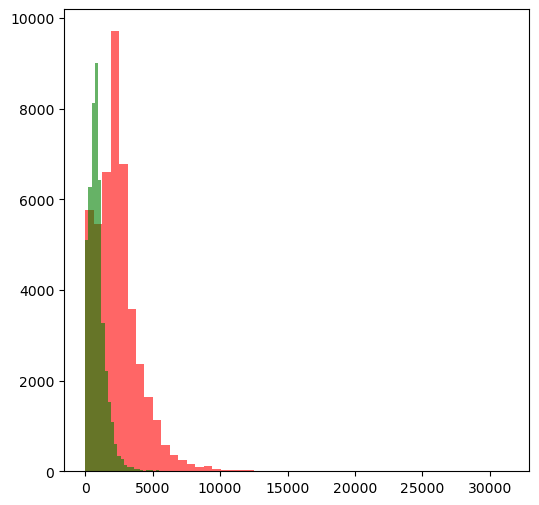

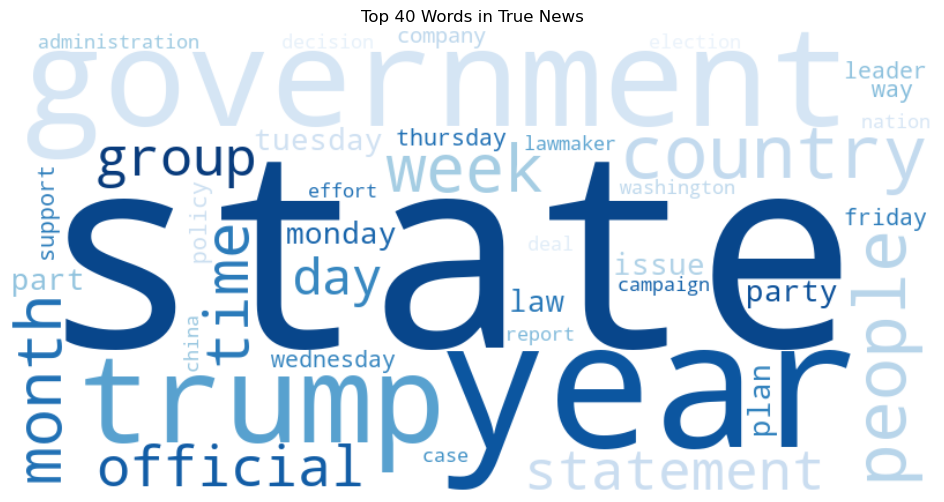

In [ ]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text
from wordcloud import WordCloud

# Filter news with label 1 (True News) and convert to it string and handle any non-string values
true_news = train_df[train_df['News_label'] == 1]['lemmatized_text']
true_text = " ".join(map(str, true_news.dropna()))
# Generate word cloud for True News
wordcloud = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Blues').generate(true_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Top 40 Words in True News")
plt.show()


##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

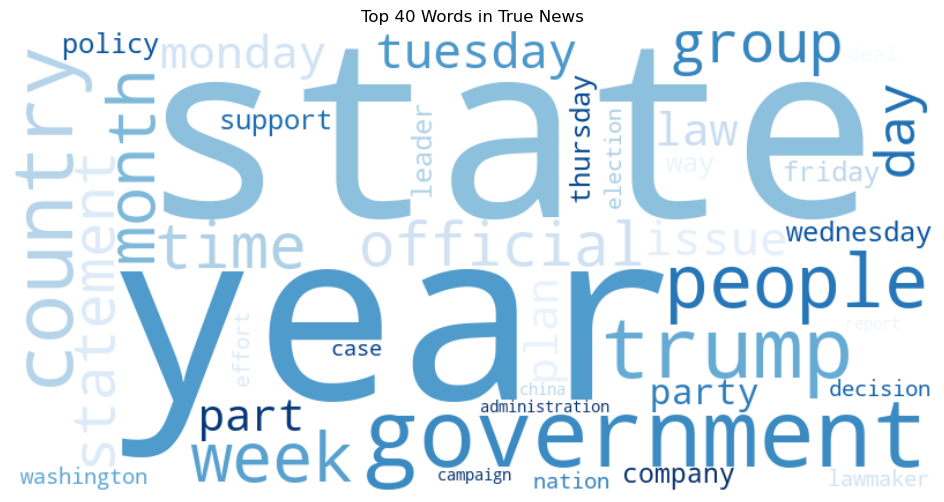

In [ ]:
## Use a word cloud find the top 40 words by frequency among fake news in the training data after processing the text

# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values
fake_news = train_df[train_df['News_label'] == 0]['lemmatized_text']
fake_text = " ".join(map(str, fake_news.dropna()))
# Generate word cloud for Fake News
wordcloud = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Blues').generate(true_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Top 40 Words in True News")
plt.show()

### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [ ]:
# Write a function to get the specified top n-grams
def get_top_ngrams(text, n, num_ngrams):
    tokens = word_tokenize(text)
    ngrams = list(nltk.ngrams(tokens, n))
    ngram_freq = Counter(ngrams)
    top_ngrams = [item[0] for item in ngram_freq.most_common(num_ngrams)]
    return top_ngrams

##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [ ]:
# Handle NaN values in the text data
train_df['lemmatized_text'].fillna('', inplace=True)

### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

In [ ]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
print("Top 10 Unigrams in True News:")
top_unigrams = get_top_ngrams(" ".join(train_df[train_df['News_label'] == 1]['lemmatized_text']), 1, 10)

Top 10 Unigrams in True News:


##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [ ]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
print("Top 10 Bigrams in True News:")
top_bigrams = get_top_ngrams(" ".join(train_df[train_df['News_label'] == 1]['lemmatized_text']), 2, 10)

Top 10 Bigrams in True News:


##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [ ]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
print("Top 10 Trigrams in True News:")
top_trigrams = get_top_ngrams(" ".join(train_df[train_df['News_label'] == 1]['lemmatized_text']), 3, 10)

Top 10 Trigrams in True News:


### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

In [ ]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
print("Top 10 Unigrams in Fake News:")
top_unigrams = get_top_ngrams(" ".join(train_df[train_df['News_label'] == 0]['lemmatized_text']), 1, 10)

Top 10 Unigrams in Fake News:


##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [ ]:
# Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
print("Top 10 Bigrams in Fake News:")
top_bigrams = get_top_ngrams(" ".join(train_df[train_df['News_label'] == 0]['lemmatized_text']), 2, 10)

Top 10 Bigrams in Fake News:


##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [ ]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
print("Top 10 Trigrams in Fake News:")
top_trigrams = get_top_ngrams(" ".join(train_df[train_df['News_label'] == 0]['lemmatized_text']), 3, 10)

Top 10 Trigrams in Fake News:


## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [ ]:
# Add a new column to calculate the character length of cleaned news text

# Add a new column to calculate the character length of lemmatized news text with POS tags removed


##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

In [ ]:
# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text

# Add histogram for lemmatized news text with POS tags removed


### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

In [ ]:
## Use a word cloud find the top 40 words by frequency among true news after processing the text

# Generate word cloud for True News


##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

In [ ]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text

# Generate word cloud for Fake News


### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [ ]:
## Write a function to get the specified top n-grams


##### 5.3.2 Handle the NaN values

In [ ]:
## First handle NaN values in the text data


### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

In [ ]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph


##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

In [ ]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph


##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

In [ ]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph


### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

In [ ]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

In [ ]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

In [ ]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph


## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [ ]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"
import gensim.downloader as api
word2vec_model = api.load('word2vec-google-news-300')

### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
## Write your code here to extract the vectors from the Word2Vec model for both training and validation data
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from nltk.tokenize import word_tokenize

train_df['clean_news_text'] = train_df['clean_news_text'].fillna('').astype(str)
val_df['clean_news_text'] = val_df['clean_news_text'].fillna('').astype(str)

train_df['vectorized_text'] = train_df['clean_news_text'].apply(lambda x: [word2vec_model[word] for word in word_tokenize(x) if word in word2vec_model] )
val_df['vectorized_text'] = val_df['clean_news_text'].apply(lambda x: [word2vec_model[word] for word in word_tokenize(x) if word in word2vec_model])


## Extract the target variable for the training data and validation data
train_target = train_df['News_label']
val_target = val_df['News_label']

## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [ ]:
## Initialise Logistic Regression model
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

# Function to average word embeddings
def average_word_vectors(text, model, vector_size):
    tokens = word_tokenize(text)
    vectors = [model[word] for word in tokens if word in model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

# Vector size from model
vector_size = word2vec_model.vector_size

## Train Decision Tree model on training data
X_train = np.array([average_word_vectors(text, word2vec_model, vector_size) for text in tqdm(train_df['clean_news_text'])])
X_val = np.array([average_word_vectors(text, word2vec_model, vector_size) for text in tqdm(val_df['clean_news_text'])])

# Target variables
y_train = train_df['News_label'].values
y_val = val_df['News_label'].values

## Predict on validation data
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
val_predictions = lr_model.predict(X_val)


100%|██████████| 13470/13470 [00:30<00:00, 435.01it/s]


##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [ ]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
print("Accuracy:", accuracy_score(val_target, val_predictions))
print("Precision:", precision_score(val_target, val_predictions))
print("Recall:", recall_score(val_target, val_predictions))
print("F1-score:", f1_score(val_target, val_predictions))

Accuracy: 0.9489977728285078
Precision: 0.9438564196962724
Recall: 0.9504170528266914
F1-score: 0.9471253752020319


In [ ]:
# Classification Report
classification_report(val_target, val_predictions)

'              precision    recall  f1-score   support\n\n           0       0.95      0.95      0.95      6996\n           1       0.94      0.95      0.95      6474\n\n    accuracy                           0.95     13470\n   macro avg       0.95      0.95      0.95     13470\nweighted avg       0.95      0.95      0.95     13470\n'

### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [ ]:
## Initialise Decision Tree model
from sklearn.tree import DecisionTreeClassifier

## Train Decision Tree model on training data
X_train = np.array([average_word_vectors(text, word2vec_model, vector_size) for text in tqdm(train_df['clean_news_text'])])
X_val = np.array([average_word_vectors(text, word2vec_model, vector_size) for text in tqdm(val_df['clean_news_text'])])

# Target variables
y_train = train_df['News_label'].values
y_val = val_df['News_label'].values

## Predict on validation data
lr_model = DecisionTreeClassifier()
lr_model.fit(X_train, y_train)
val_predictions = lr_model.predict(X_val)


100%|██████████| 13470/13470 [00:30<00:00, 441.17it/s]


##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [ ]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
print("Accuracy:", accuracy_score(val_target, val_predictions))

Accuracy: 0.8900519673348181


In [ ]:
# Classification Report
classification_report(val_target, val_predictions)

'              precision    recall  f1-score   support\n\n           0       0.88      0.91      0.90      6996\n           1       0.90      0.87      0.88      6474\n\n    accuracy                           0.89     13470\n   macro avg       0.89      0.89      0.89     13470\nweighted avg       0.89      0.89      0.89     13470\n'

### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [ ]:
## Initialise Random Forest model
from sklearn.ensemble import RandomForestClassifier
## Train Random Forest model on training data

X_train = np.array([average_word_vectors(text, word2vec_model, vector_size) for text in tqdm(train_df['clean_news_text'])])
X_val = np.array([average_word_vectors(text, word2vec_model, vector_size) for text in tqdm(val_df['clean_news_text'])])

# Target variables
y_train = train_df['News_label'].values
y_val = val_df['News_label'].values

## Predict on validation data
dt_model = RandomForestClassifier()
dt_model.fit(train_df['vectorized_text'].tolist(), train_target)
val_predictions = dt_model.predict(val_df['vectorized_text'].tolist())

100%|██████████| 13470/13470 [00:30<00:00, 447.65it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (31428,) + inhomogeneous part.

 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [ ]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
print("Accuracy:", accuracy_score(val_target, val_predictions))

In [ ]:
# Classification Report
classification_report(val_target, val_predictions)

## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.

#From Logistic Regression we have an accuracy of 94%, and from DecisionTree and RandomForest Model we have received 89%.